# Я художник, я так вижу, визуализация данных в питоне

# I. Numpy

### Импортируйте NumPy

In [192]:
import numpy as np

### Создайте одномерный массив размера 10, заполненный нулями и пятым элемент равным 1. Трансформируйте в двумерный массив.

In [193]:
a1 = np.array([0, 0, 0, 0, 5, 0, 0, 0, 0, 0])
a1 = a1.reshape(1, -1)
a2 = a1.reshape(2, -1)
a3 = a1.reshape(5, -1)
a4 = a1.reshape(10, -1)

### Создайте одномерный массив со значениями от 10 до 49 и разверните его (первый элемент становится последним). Найдите в нем все четные элементы.

In [194]:
a = np.arange(10, 50)
a1_reverse = np.flip(a)
a2_reverse = a[::-1]

### Создайте двумерный массив 3x3 со значениями от 0 до 8

In [195]:
a = np.arange(0, 9).reshape(3, 3)

### Создайте массив 4x3x2 со случайными значениями. Найти его минимум и максимум.

In [196]:
a = np.random.rand(4, 3, 2)
max = a.max()
min = a.min()

### Создайте два двумерных массива размерами 6x4 и 4x3 и произведите их матричное умножение. 

In [197]:
a = np.random.rand(6, 4)
b = np.random.rand(4, 3)
c = a @ b

### Создайте случайный двумерный массив 7x7, найти у него среднее и стандартное оклонение. Нормализуйте этот массив.

In [198]:
a = np.random.rand(7, 7)
mean = a.mean()
std = a.std()
normalized = (a - mean) / std

# II. Pandas

### Импортируйте: pandas, matplotlib, seaborn

In [199]:

import matplotlib.pyplot as plt
import seaborn as sns

### Загрузите датасет Tips из набора датасетов seaborn

In [200]:
tips = sns.load_dataset('tips')

### Посмотрите на первые 5 строчек

In [201]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Узнайте сколько всего строчек и колонок в данных

In [202]:
tips.shape

(244, 7)

### Проверьте есть ли пропуски в данных

In [203]:
tips.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

### Посмотрите на распределение числовых признаков

In [204]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


### Найдите максимальное значение 'total_bill'

In [205]:
tips['total_bill'].max()

np.float64(50.81)

### Найдите количество курящих людей

In [206]:
smoker_count = (tips['smoker'] == 'Yes').sum()

### Узнайте какой средний 'total_bill' в зависимости от 'day'

In [207]:
group_by_day = tips.groupby('day', observed=False)['total_bill'].mean()
print(group_by_day)

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64


### Отберите строчки с 'total_bill' больше медианы и узнайте какой средний 'tip' в зависимости от 'sex'

In [208]:
total_bill_median = tips['total_bill'].median()
tips[tips['total_bill'] > total_bill_median].groupby('sex', observed=False)['tip'].mean()

sex
Male      3.756404
Female    3.663939
Name: tip, dtype: float64

### Преобразуйте признак 'smoker' в бинарный (0-No, 1-Yes)

In [209]:
tips['smoker'] = tips['smoker'].map({'No': 0, 'Yes': 1})

# III. Visualization

### Постройте гистограмму распределения признака 'total_bill'

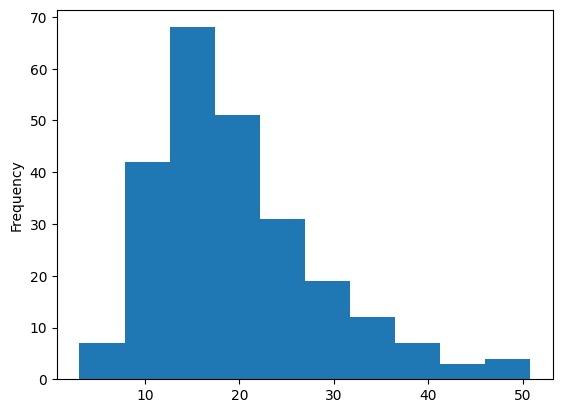

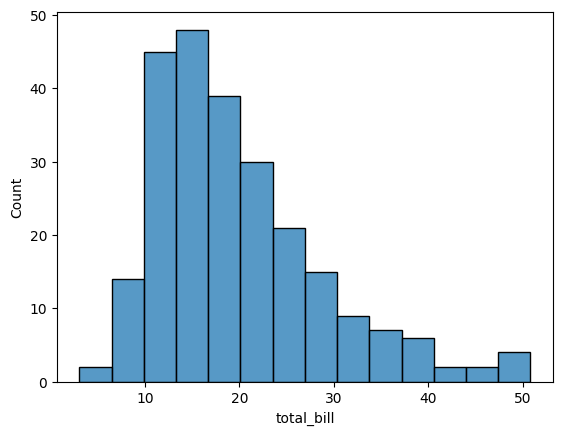

In [211]:
# 1
tips['total_bill'].plot.hist()
plt.show()

# 2
sns.histplot(tips['total_bill'])
plt.show()

### Постройте scatterplot, представляющий взаимосвязь между признаками 'total_bill' и 'tip'

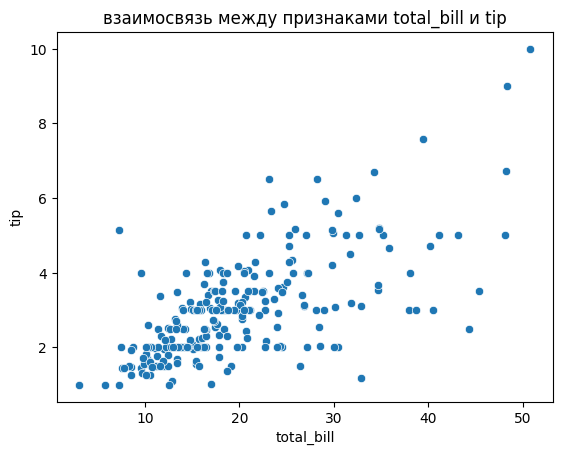

In [218]:
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip'
)
plt.title('Взаимосвязь между признаками total_bill и tip');

### Постройте pairplot

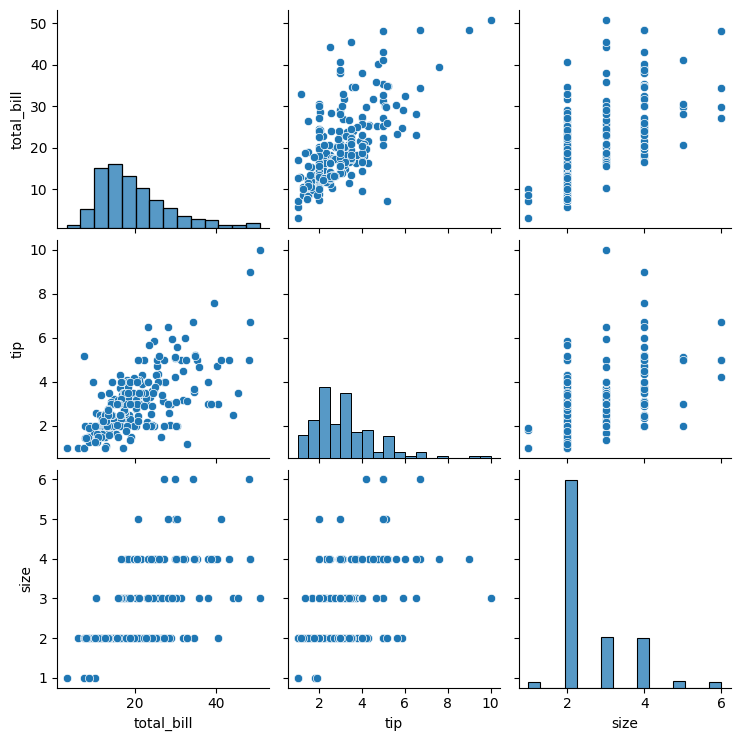

In [222]:
sns.pairplot(
    tips,
);

### Постройте график взаимосвязи между признаками 'total_bill' и 'day'

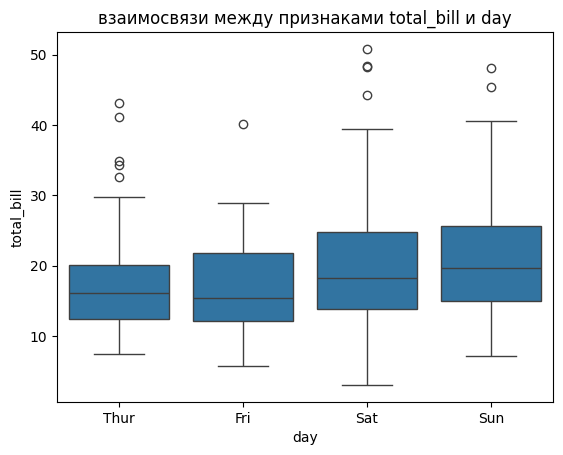

In [223]:
sns.boxplot(data=tips, x='day', y='total_bill')
plt.title('взаимосвязи между признаками total_bill и day');

### Постройте две гистограммы распределения признака 'tip' в зависимости от категорий 'time'

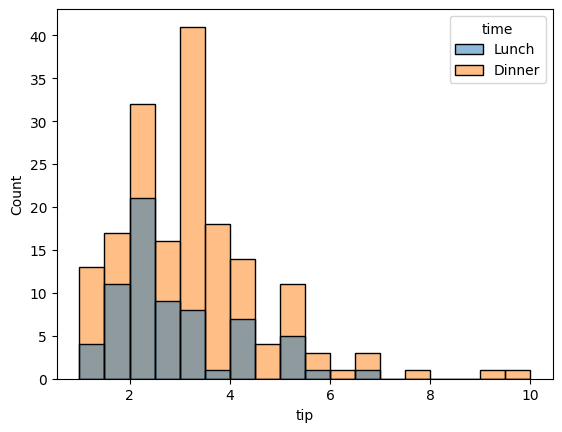

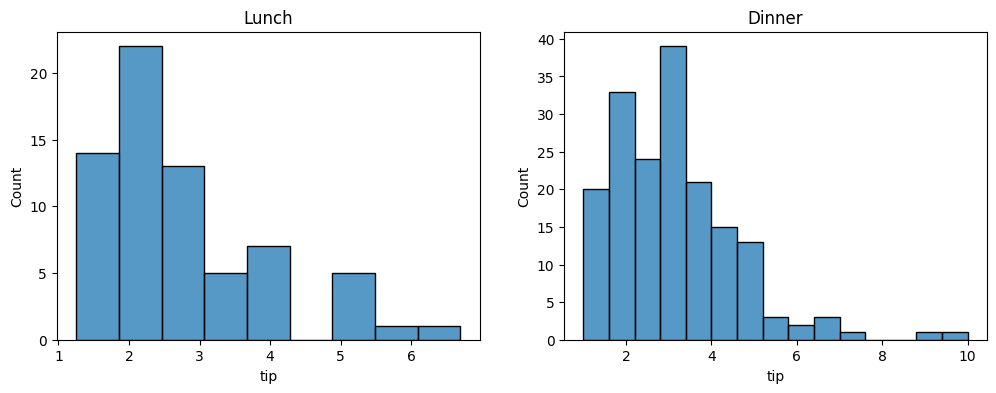

In [225]:
sns.histplot(data=tips, x='tip', hue='time')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(tips[tips['time'] == 'Lunch']['tip'], ax=axes[0])
axes[0].set_title('Lunch')

sns.histplot(tips[tips['time'] == 'Dinner']['tip'], ax=axes[1])
axes[1].set_title('Dinner')
plt.show()

### Постройте два графика scatterplot, представляющих взаимосвязь между признаками 'total_bill' и 'tip' один для Male, другой для Female и раскрасьте точки в зависимоти от признака 'smoker'

Text(0.5, 1.0, 'Female')

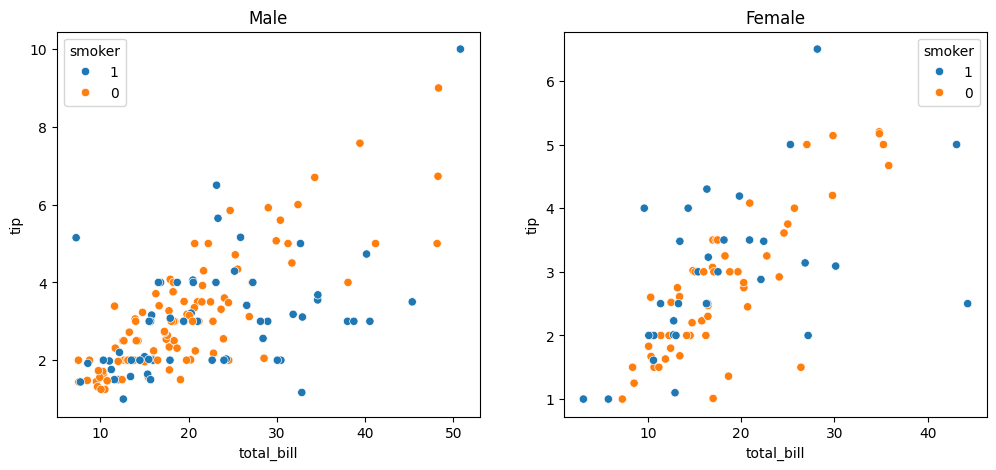

In [226]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=tips[tips['sex'] == 'Male'], x='total_bill', y='tip', hue='smoker', ax=axes[0])
axes[0].set_title('Male')

sns.scatterplot(data=tips[tips['sex'] == 'Female'], x='total_bill', y='tip', hue='smoker', ax=axes[1])
axes[1].set_title('Female')

## Сделайте выводы по анализу датасета и построенным графикам. По желанию можете продолжить анализ данных и также отразить это в выводах.

- средний счет 19.8, средние чаевые 3.0
- на выходных средний счет (около 21) больше, чем четверг и пятницу (около 17)
- чем больше счёт, тем больше чаевые,
- на выходных больше разброс счета
- большинство посещений - компании из 2 человек,
- чем больше компания, тем выше счёт,
- ужинают чаще, чем обедают
- у мужчин больше счет и чаевые